In [8]:

"""
M evaluation — metric surrogate fit on a sample-level holdout.

Loads the latest m_train.py checkpoint, predicts PSNR and CLIP on held-out
grid cells, and reports global error, calibration, and surface fidelity.
"""

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "settings.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "models" / "modified-classification"
ROOT = NOTEBOOK_DIR.parents[1]
for p in (ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model_m import MetricPredictor
from model_t import TimestepPredictor, ScalarStats
from data_io import load_data, precompute_embeddings, df_to_metric_grids
from settings import *

def fig_title(subtitle: str) -> str:
    return f"{subtitle} for M on {METRICS_CSV.stem}, $\\delta={{{TARGET_T_DELTA}}}$"

# Latest m_train run + sample-level holdout (images not seen during training).
run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
full_df = load_data()
all_sids = sorted(full_df.sample_id.unique())
rng = np.random.default_rng(SEED)
perm = rng.permutation(all_sids)
n_holdout = max(1, round(0.2 * len(perm)))
holdout_sids = sorted(perm[:n_holdout])
holdout_df = full_df[full_df.sample_id.isin(holdout_sids)].copy()
print(f"Run: {RUN_DIR.name}  holdout: {len(holdout_sids)} images  cells: {len(holdout_df)}")

T_START_VALUES = np.sort(holdout_df.t_start.unique())
T_END_VALUES = np.sort(holdout_df.t_end.unique())
N1, N2 = len(T_START_VALUES), len(T_END_VALUES)
CELLS = N1 * N2
SAMPLE_IDS = sorted(holdout_df.sample_id.unique())
N_IMG = len(SAMPLE_IDS)

weights_path = RUN_DIR / "regressor_weights.pt"
ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MetricPredictor(freeze_encoders=FREEZE_ENCODERS, device=DEVICE)
model.regressor.load_state_dict(ckpt["regressor_state_dict"])
model.regressor.set_target_stats(ckpt["target_mean"], ckpt["target_std"])
model.regressor.to(DEVICE).eval()

emb = precompute_embeddings(holdout_df.drop_duplicates("sample_id"), model, DEVICE)
t_predictor = TimestepPredictor(model, t_start_values=T_START_VALUES, t_end_values=T_END_VALUES)

true_psnr, _ = df_to_metric_grids(holdout_df, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, "psnr")
true_clip, _ = df_to_metric_grids(holdout_df, SAMPLE_IDS, T_START_VALUES, T_END_VALUES, "clip")
pred_psnr = np.zeros_like(true_psnr)
pred_clip = np.zeros_like(true_clip)
for k, sid in enumerate(SAMPLE_IDS):
    e = emb[sid]
    grid = t_predictor.predict_grid_from_emb(e["img"], e["src"], e["tar"])
    pred_psnr[k], pred_clip[k] = grid.psnr_grid, grid.clip_grid

print(f"holdout grids: {true_psnr.shape}  ({N_IMG} images x {N1}x{N2} cells)")


Run: 20260701_153347  holdout: 2 images  cells: 242


Loading weights: 100%|██████████| 372/372 [00:00<00:00, 10447.91it/s]


RuntimeError: Error(s) in loading state_dict for MetricRegressor:
	Missing key(s) in state_dict: "t_mlp.0.weight", "t_mlp.0.bias", "clip_body.0.weight", "clip_body.0.bias", "clip_body.1.weight", "clip_body.1.bias", "clip_body.4.weight", "clip_body.4.bias", "clip_body.7.weight", "clip_body.7.bias". 
	Unexpected key(s) in state_dict: "img_proj.0.weight", "img_proj.0.bias", "img_proj.1.weight", "img_proj.1.bias", "text_proj.0.weight", "text_proj.0.bias", "text_proj.1.weight", "text_proj.1.bias", "t_encoder.0.weight", "t_encoder.0.bias", "t_encoder.2.weight", "t_encoder.2.bias", "clip_body.blocks.0.linear.weight", "clip_body.blocks.0.linear.bias", "clip_body.blocks.0.norm.weight", "clip_body.blocks.0.norm.bias", "clip_body.blocks.0.film.to_gamma.weight", "clip_body.blocks.0.film.to_gamma.bias", "clip_body.blocks.0.film.to_beta.weight", "clip_body.blocks.0.film.to_beta.bias", "clip_body.blocks.1.linear.weight", "clip_body.blocks.1.linear.bias", "clip_body.blocks.1.norm.weight", "clip_body.b

In [ ]:

"""Global MAE / RMSE / R² per metric head on all holdout cells."""

def _metrics(true_g, pred_g, name):
    e = (pred_g - true_g).ravel()
    t = true_g.ravel()
    ss_res = (e ** 2).sum()
    ss_tot = ((t - t.mean()) ** 2).sum()
    return {
        "metric": name,
        "mae": float(np.abs(e).mean()),
        "rmse": float(np.sqrt((e ** 2).mean())),
        "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
    }

rows = [_metrics(true_psnr, pred_psnr, "psnr"), _metrics(true_clip, pred_clip, "clip")]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


metric      mae     rmse       r2
  psnr 4.070546 4.931264 0.317019
  clip 0.024159 0.031045 0.694847


within-image CLIP range: median=0.1340  p10=0.1221  MAE=0.024
within-image PSNR range: median=25.013  p10=23.812  MAE=4.071


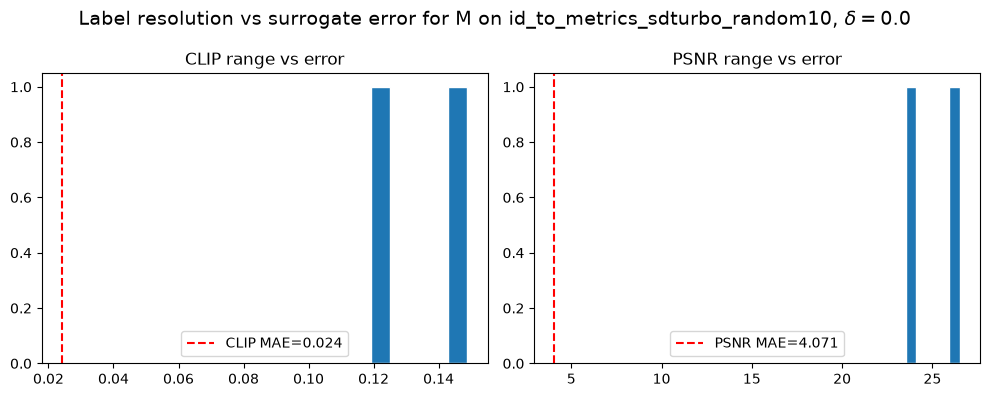

In [ ]:

"""Within-image metric range vs surrogate MAE — can M resolve grid variation?"""

clip_range = true_clip.max(axis=(1, 2)) - true_clip.min(axis=(1, 2))
psnr_range = true_psnr.max(axis=(1, 2)) - true_psnr.min(axis=(1, 2))
clip_mae = np.abs(pred_clip - true_clip).mean()
psnr_mae = np.abs(pred_psnr - true_psnr).mean()

print(f"within-image CLIP range: median={np.median(clip_range):.4f}  p10={np.percentile(clip_range, 10):.4f}  MAE={clip_mae:.3f}")
print(f"within-image PSNR range: median={np.median(psnr_range):.3f}  p10={np.percentile(psnr_range, 10):.3f}  MAE={psnr_mae:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(clip_range, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
axes[0].axvline(clip_mae, color="r", linestyle="--", label=f"CLIP MAE={clip_mae:.3f}")
axes[0].legend(); axes[0].set_title("CLIP range vs error")
axes[1].hist(psnr_range, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
axes[1].axvline(psnr_mae, color="r", linestyle="--", label=f"PSNR MAE={psnr_mae:.3f}")
axes[1].legend(); axes[1].set_title("PSNR range vs error")
fig.suptitle(fig_title("Label resolution vs surrogate error"), fontsize=14)
plt.tight_layout(); plt.show()


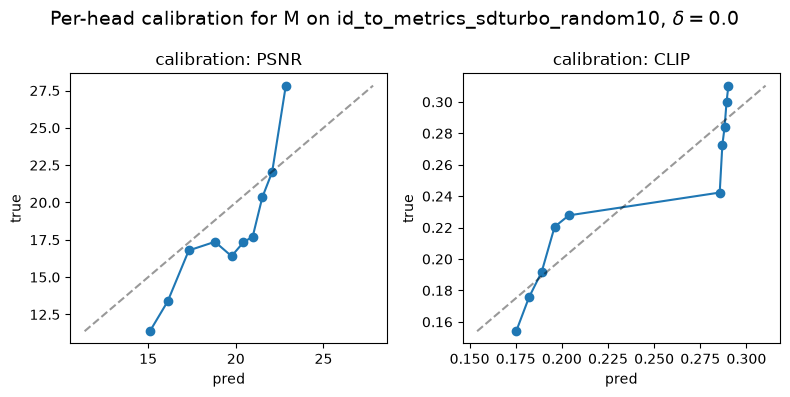

In [ ]:

"""Per-head calibration: compression toward the mean signals poor ranking."""

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, true_g, pred_g, name in [(axes[0], true_psnr, pred_psnr, "PSNR"), (axes[1], true_clip, pred_clip, "CLIP")]:
    p, t = pred_g.ravel(), true_g.ravel()
    bins = np.quantile(p, np.linspace(0, 1, 11)); bins[0] -= 1e-6; bins[-1] += 1e-6
    idx = np.digitize(p, bins)
    bx, by = [], []
    for b in range(1, 11):
        mask = idx == b
        if mask.any():
            bx.append(p[mask].mean()); by.append(t[mask].mean())
    ax.plot(bx, by, "o-")
    lo, hi = min(bx + by), max(bx + by)
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_title(f"calibration: {name}"); ax.set_xlabel("pred"); ax.set_ylabel("true")
fig.suptitle(fig_title("Per-head calibration"), fontsize=14)
plt.tight_layout(); plt.show()


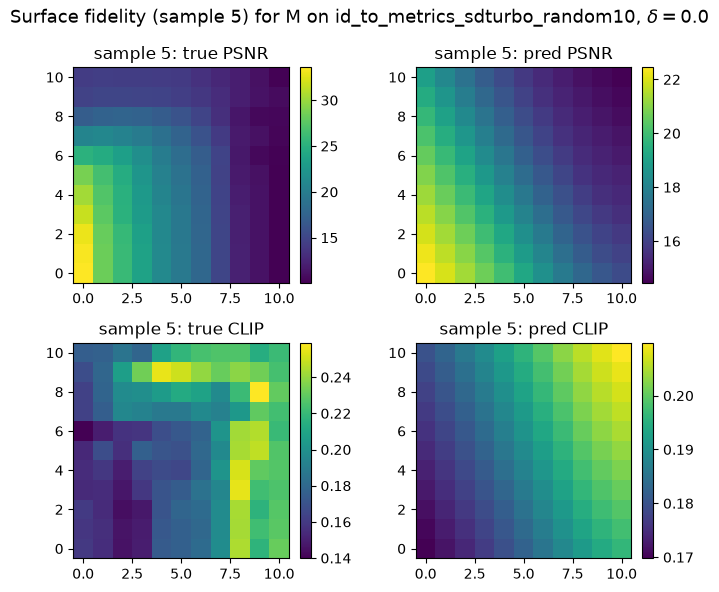

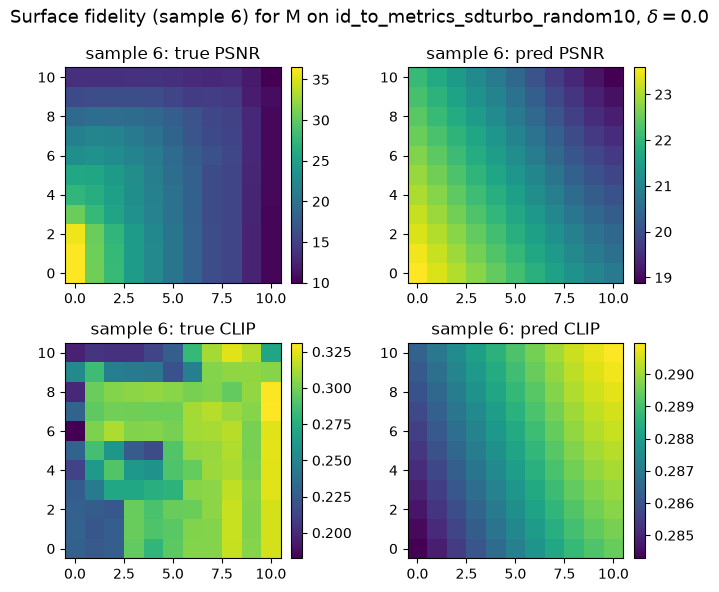

In [ ]:

"""Surface-shape fidelity: true vs predicted PSNR/CLIP heatmaps on random holdout images."""

rng = np.random.default_rng(SEED)
pick = rng.choice(N_IMG, size=min(4, N_IMG), replace=False)
for k in pick:
    fig, axes = plt.subplots(2, 2, figsize=(7, 6))
    for ax, g, title in [
        (axes[0, 0], true_psnr[k], "true PSNR"), (axes[0, 1], pred_psnr[k], "pred PSNR"),
        (axes[1, 0], true_clip[k], "true CLIP"), (axes[1, 1], pred_clip[k], "pred CLIP"),
    ]:
        im = ax.imshow(g, origin="lower", cmap="viridis")
        ax.set_title(f"sample {SAMPLE_IDS[k]}: {title}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(fig_title(f"Surface fidelity (sample {SAMPLE_IDS[k]})"), fontsize=13)
    plt.tight_layout(); plt.show()


In [ ]:

"""M evaluation summary."""

print(fig_title("M summary"))
for row in rows:
    print(f"  {row['metric']:5s}  MAE={row['mae']:.3f}  RMSE={row['rmse']:.3f}  R2={row['r2']:.3f}")
print(f"  holdout: {N_IMG} images  grid: {N1}x{N2}={CELLS}")


M summary for M on id_to_metrics_sdturbo_random10, $\delta={0.0}$
  psnr   MAE=4.071  RMSE=4.931  R2=0.317
  clip   MAE=0.024  RMSE=0.031  R2=0.695
  holdout: 2 images  grid: 11x11=121
